# Data Preprocessing — Corrected Pipeline
Fixed issues:
1. Drop bad rows BEFORE aggregating
2. Proper fiber grouping (not just PVA vs Other)
3. No leakage — log transform instead of fitted QuantileTransformer
4. model_name passed as parameter
5. Consistent fiber grouping across raw and cleaned datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available')

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM not available')
print('Libraries loaded successfully')

LightGBM not available
Libraries loaded successfully


## Step 1 — Load Raw Data

In [3]:
df_raw = pd.read_excel('Tension Test_VIT.xlsx')
print(f'Raw dataset shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')

Raw dataset shape: (506, 24)
Columns: ['Mixture', 'Specimen', 'Fiber Type', 'Fiber Volume', 'Length (mm)', 'Diameter (mm)', 'L/D', 'Shape Factor', 'RI', 'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer / SP', 'Fiber', 'C/B', 'W/C', 'W/B', 'Second Stress', 'Second Strain']


## Step 2 — Drop Identifier & Zero-Info Columns

In [4]:
cols_to_drop = ['Mixture', 'Specimen', 'Shape Factor']
df = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])
print(f'Shape after dropping identifier columns: {df.shape}')

Shape after dropping identifier columns: (506, 21)


## Step 3 — Drop Bad Rows FIRST (before any aggregation)
**Bug fix:** Original code dropped nulls after groupby — this let zero/null rows pollute medians.

In [5]:
print(f'Rows before cleaning: {len(df)}')

# Drop rows with missing Fiber Type, Length, Diameter
df = df.dropna(subset=['Fiber Type', 'Length (mm)', 'Diameter (mm)'])
print(f'After dropping NaN fiber/length/diameter: {len(df)}')

# Drop zero-value fiber rows (no-fiber control specimens)
df = df[(df['Length (mm)'] > 0) & (df['Diameter (mm)'] > 0)]
print(f'After dropping zero-length/diameter rows: {len(df)}')

# Drop rows where targets are missing
df = df.dropna(subset=['Second Stress', 'Second Strain'])
print(f'After dropping missing targets: {len(df)}')

Rows before cleaning: 506
After dropping NaN fiber/length/diameter: 503
After dropping zero-length/diameter rows: 503
After dropping missing targets: 503


## Step 4 — Fiber Type Grouping
**Bug fix:** Original code collapsed everything into PVA vs Other — losing PE, PP, Steel signal.

In [6]:
def group_fiber(fiber_string):
    f = str(fiber_string).upper().strip()
    if f == 'PVA FIBER':                          return 'PVA Fiber'
    return 'Other'

df['Fiber Type'] = df['Fiber Type'].apply(group_fiber)

print('Fiber Type distribution after grouping:')
print(df['Fiber Type'].value_counts())
print(f'\nTotal rows: {len(df)}')

Fiber Type distribution after grouping:
Fiber Type
PVA Fiber    263
Other        240
Name: count, dtype: int64

Total rows: 503


## Step 5 — Duplicate Analysis (before aggregation)

In [7]:
target_vars  = ['Second Stress', 'Second Strain']
feature_cols = [c for c in df.columns if c not in target_vars]

n_total       = len(df)
n_unique      = df.drop_duplicates(subset=feature_cols).shape[0]
n_dupes       = n_total - n_unique

print('=' * 55)
print('  DUPLICATE ANALYSIS')
print('=' * 55)
print(f'  Total rows            : {n_total}')
print(f'  Unique mix designs    : {n_unique}  ({100*n_unique/n_total:.1f}%)')
print(f'  Replicated rows       : {n_dupes}  ({100*n_dupes/n_total:.1f}%)')

# Coefficient of variation for targets across duplicates
grouped  = df.groupby(feature_cols)
dup_only = grouped.filter(lambda x: len(x) > 1)
agg      = dup_only.groupby(feature_cols)[target_vars].agg(['mean','std'])

cv_stress = (agg[('Second Stress','std')] / agg[('Second Stress','mean')]).mean() * 100
cv_strain = (agg[('Second Strain','std')] / agg[('Second Strain','mean')]).mean() * 100

print(f'\n  Avg CV% Stress across replicates: {cv_stress:.2f}%')
print(f'  Avg CV% Strain across replicates: {cv_strain:.2f}%')
print('\n  High strain CV confirms experimental noise is the limiting factor for strain R²')

  DUPLICATE ANALYSIS
  Total rows            : 503
  Unique mix designs    : 148  (29.4%)
  Replicated rows       : 355  (70.6%)

  Avg CV% Stress across replicates: 10.09%
  Avg CV% Strain across replicates: 42.72%

  High strain CV confirms experimental noise is the limiting factor for strain R²


## Step 6 — Aggregate Duplicates Using Median
Reduces 503 noisy rows → ~155 unique, clean mix designs

In [8]:
df_unique = df.groupby(feature_cols, as_index=False).agg(
    Second_Stress = ('Second Stress', 'median'),
    Second_Strain = ('Second Strain', 'median'),
    n_replicates  = ('Second Stress', 'count')
)

# Rename back to original column names
df_unique = df_unique.rename(columns={
    'Second_Stress': 'Second Stress',
    'Second_Strain': 'Second Strain'
})

print(f'Rows after aggregation: {len(df_unique)}')
print(f'\nReplicate distribution:')
print(df_unique['n_replicates'].value_counts().sort_index())
print(f'\nFiber Type counts in cleaned dataset:')
print(df_unique['Fiber Type'].value_counts())

Rows after aggregation: 148

Replicate distribution:
n_replicates
1     62
2     21
3     24
4     12
5      2
6     14
7      1
8      2
9      1
11     1
12     1
15     1
18     3
19     1
20     1
22     1
Name: count, dtype: int64

Fiber Type counts in cleaned dataset:
Fiber Type
PVA Fiber    78
Other        70
Name: count, dtype: int64


## Step 7 — Target Distribution Analysis & Transformation
**Bug fix:** Use log1p (no fitting needed) instead of QuantileTransformer to avoid leakage

Stress — Skewness: 0.9037  |  Kurtosis: 2.5338
Strain — Skewness: 1.3855  |  Kurtosis: 2.7492
Strain skewness after log1p            : 1.3147
Strain skewness after Yeo-Johnson       : 0.1496
Strain skewness after QuantileTransformer: -0.0049


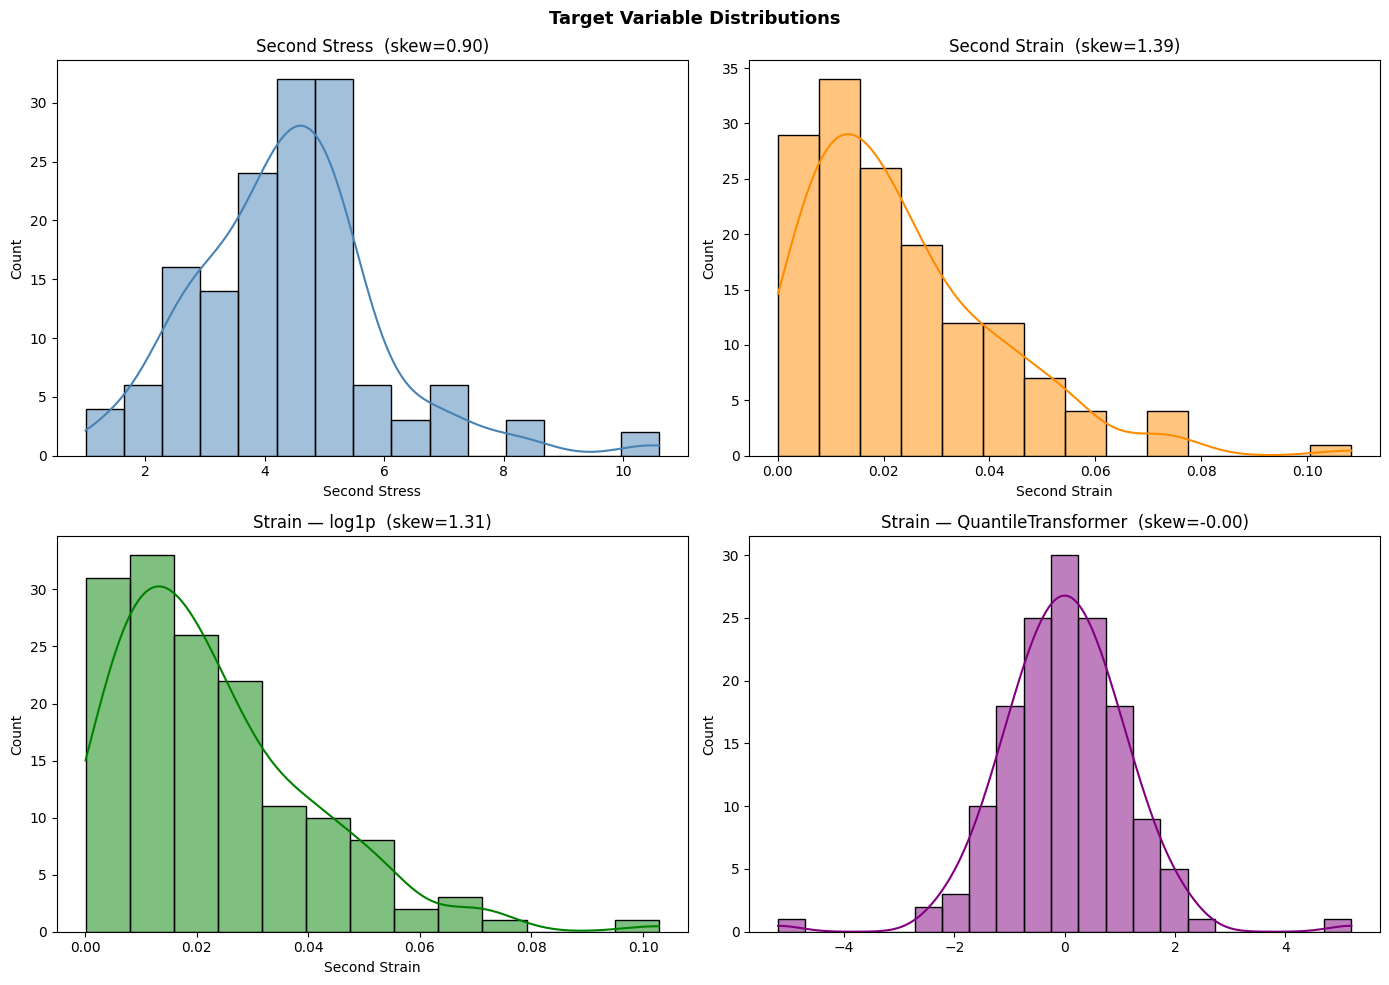

>>> QuantileTransformer wins. Applied INSIDE the pipeline
    via TransformedTargetRegressor so it only fits on training data (no leakage).


In [9]:
stress = df_unique["Second Stress"]
strain = df_unique["Second Strain"]

print(f"Stress — Skewness: {stress.skew():.4f}  |  Kurtosis: {stress.kurtosis():.4f}")
print(f"Strain — Skewness: {strain.skew():.4f}  |  Kurtosis: {strain.kurtosis():.4f}")

# Compare transformations
strain_log = np.log1p(strain)
strain_yj, _ = stats.yeojohnson(strain)
qt = QuantileTransformer(n_quantiles=min(len(strain), 100), output_distribution="normal", random_state=42)
strain_qt = qt.fit_transform(strain.values.reshape(-1, 1)).ravel()

print(f"Strain skewness after log1p            : {strain_log.skew():.4f}")
print(f"Strain skewness after Yeo-Johnson       : {pd.Series(strain_yj).skew():.4f}")
print(f"Strain skewness after QuantileTransformer: {pd.Series(strain_qt).skew():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Target Variable Distributions", fontsize=13, fontweight="bold")

sns.histplot(stress,       kde=True, ax=axes[0][0], color="steelblue")
axes[0][0].set_title(f"Second Stress  (skew={stress.skew():.2f})")

sns.histplot(strain,       kde=True, ax=axes[0][1], color="darkorange")
axes[0][1].set_title(f"Second Strain  (skew={strain.skew():.2f})")

sns.histplot(strain_log,   kde=True, ax=axes[1][0], color="green")
axes[1][0].set_title(f"Strain — log1p  (skew={strain_log.skew():.2f})")

sns.histplot(pd.Series(strain_qt), kde=True, ax=axes[1][1], color="purple")
axes[1][1].set_title(f"Strain — QuantileTransformer  (skew={pd.Series(strain_qt).skew():.2f})")

plt.tight_layout()
plt.show()
print(">>> QuantileTransformer wins. Applied INSIDE the pipeline")
print("    via TransformedTargetRegressor so it only fits on training data (no leakage).")


## Step 8 — Prepare Features for Modelling

In [10]:
def prep_data(df_in, target_stress, target_strain):
    """
    Prepare X and y.
    Uses OneHotEncoder for Fiber Type.
    StandardScaler for numeric features.
    Returns pipeline-ready X DataFrame and y Series/DataFrame.
    """
    drop_cols = ['Second Stress', 'Second Strain', 'Second Strain',
                 'n_replicates'] + [target_stress, target_strain]
    X = df_in.drop(columns=[c for c in drop_cols if c in df_in.columns],
                   errors='ignore')
    y_stress = df_in[target_stress]
    y_strain = df_in[target_strain]
    return X, y_stress, y_strain


def build_pipeline(model, X):
    """
    Build sklearn Pipeline with ColumnTransformer:
    - OneHotEncoder for Fiber Type
    - StandardScaler for all numeric columns
    """
    cat_cols = ['Fiber Type']
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])


# Cleaned dataset
X_clean, ys_clean, yt_clean = prep_data(
    df_unique, 'Second Stress', 'Second Strain'
)

# Raw dataset (with duplicates) — same fiber grouping for fair comparison
df_raw_grouped = df.copy()   # df already has grouped Fiber Type from Step 4
X_raw, ys_raw, yt_raw = prep_data(
    df_raw_grouped, 'Second Stress', 'Second Strain'
)
yt_raw_log = np.log1p(yt_raw)   # log transform raw strain too

print(f'Clean X shape : {X_clean.shape}')
print(f'Raw   X shape : {X_raw.shape}')
print(f'\nFeature columns: {X_clean.columns.tolist()}')

Clean X shape : (148, 19)
Raw   X shape : (503, 19)

Feature columns: ['Fiber Type', 'Fiber Volume', 'Length (mm)', 'Diameter (mm)', 'L/D', 'RI', 'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer / SP', 'Fiber', 'C/B', 'W/C', 'W/B']


## Step 9 — Model Training & Evaluation (4 Scenarios)
We are NOT using Cross Validation. We will use a standard train/test split. Stratification is difficult for regression targets, but we can stratify by the 'Fiber Type' categorical feature.
Models to test: XGBoost, Random Forest, Extra Trees, SVR.

**4 Scenarios:**
1. Uncleaned Data (with duplicates) - Separate models for Stress and Strain
2. Uncleaned Data (with duplicates) - Joint Multi-Output model
3. Cleaned Data (Median aggregation) - Separate models
4. Cleaned Data (Median aggregation) - Joint Multi-Output model

In [11]:
from sklearn.multioutput import MultiOutputRegressor

def evaluate_model(y_true, y_pred, is_log_strain=False, target_type='Stress'):
    if is_log_strain and target_type == 'Strain':
        # Exponentiate to get back to original scale for evaluation
        y_true = np.expm1(y_true)
        y_pred = np.expm1(y_pred)
        
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, rmse, mse

results = []

# Split data. We'll stratify by Fiber Type to ensure good distribution.
X_clean_tr, X_clean_te, y_clean_str_tr, y_clean_str_te, y_clean_stn_tr, y_clean_stn_te = train_test_split(
    X_clean, ys_clean, yt_clean, test_size=0.2, random_state=42, stratify=X_clean['Fiber Type']
)

X_raw_tr, X_raw_te, y_raw_str_tr, y_raw_str_te, y_raw_stn_tr, y_raw_stn_te = train_test_split(
    X_raw, ys_raw, yt_raw_log, test_size=0.2, random_state=42, stratify=X_raw['Fiber Type']
)

# Combine targets for multi-output
Y_clean_tr = pd.concat([y_clean_str_tr, y_clean_stn_tr], axis=1)
Y_clean_te = pd.concat([y_clean_str_te, y_clean_stn_te], axis=1)

Y_raw_tr = pd.concat([y_raw_str_tr, y_raw_stn_tr], axis=1)
Y_raw_te = pd.concat([y_raw_str_te, y_raw_stn_te], axis=1)

models_to_test = {
    'ExtraTrees': ExtraTreesRegressor(random_state=42, n_estimators=100),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=100),
    'SVR': SVR(),
}
if HAS_XGB:
    models_to_test['XGBoost'] = XGBRegressor(random_state=42, n_estimators=100)

def train_and_eval(model_dict, X_tr, X_te, y_tr, y_te, scenario_name, is_multi=False, is_log_strain=False, target_name=None):
    for m_name, model in model_dict.items():
        # For SVR in multioutput
        if is_multi and m_name == 'SVR':
            pipe = build_pipeline(MultiOutputRegressor(model), X_tr)
        else:
            pipe = build_pipeline(model, X_tr)
        
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_te)
        
        if is_multi:
            # preds is a 2D array [Stress, Strain]
            r2_stress, rmse_stress, mse_stress = evaluate_model(y_te.iloc[:, 0], preds[:, 0], is_log_strain=False, target_type='Stress')
            r2_strain, rmse_strain, mse_strain = evaluate_model(y_te.iloc[:, 1], preds[:, 1], is_log_strain=is_log_strain, target_type='Strain')
            
            results.append({'Scenario': scenario_name, 'Model': m_name, 'Target': 'Stress', 'R2': r2_stress, 'RMSE': rmse_stress, 'MSE': mse_stress})
            results.append({'Scenario': scenario_name, 'Model': m_name, 'Target': 'Strain', 'R2': r2_strain, 'RMSE': rmse_strain, 'MSE': mse_strain})
        else:
            r2, rmse, mse = evaluate_model(y_te, preds, is_log_strain=is_log_strain, target_type=target_name)
            results.append({'Scenario': scenario_name, 'Model': m_name, 'Target': target_name, 'R2': r2, 'RMSE': rmse, 'MSE': mse})
            


In [12]:
print("Training Scenario 1: Raw Data - Separate Models...")
train_and_eval(models_to_test, X_raw_tr, X_raw_te, y_raw_str_tr, y_raw_str_te, '1. Raw Separate', is_multi=False, is_log_strain=False, target_name='Stress')
train_and_eval(models_to_test, X_raw_tr, X_raw_te, y_raw_stn_tr, y_raw_stn_te, '1. Raw Separate', is_multi=False, is_log_strain=True, target_name='Strain')

print("Training Scenario 2: Raw Data - Multi-Output Model...")
train_and_eval(models_to_test, X_raw_tr, X_raw_te, Y_raw_tr, Y_raw_te, '2. Raw Multi', is_multi=True, is_log_strain=True)

print("Training Scenario 3: Clean Data - Separate Models...")
train_and_eval(models_to_test, X_clean_tr, X_clean_te, y_clean_str_tr, y_clean_str_te, '3. Clean Separate', is_multi=False, is_log_strain=False, target_name='Stress')
train_and_eval(models_to_test, X_clean_tr, X_clean_te, y_clean_stn_tr, y_clean_stn_te, '3. Clean Separate', is_multi=False, is_log_strain=True, target_name='Strain')

print("Training Scenario 4: Clean Data - Multi-Output Model...")
train_and_eval(models_to_test, X_clean_tr, X_clean_te, Y_clean_tr, Y_clean_te, '4. Clean Multi', is_multi=True, is_log_strain=True)

df_res = pd.DataFrame(results)
print("\n--- ALL RESULTS ---")
print(df_res.sort_values(by=['Target', 'Scenario', 'R2'], ascending=[True, True, False]))

Training Scenario 1: Raw Data - Separate Models...
Training Scenario 2: Raw Data - Multi-Output Model...
Training Scenario 3: Clean Data - Separate Models...
Training Scenario 4: Clean Data - Multi-Output Model...

--- ALL RESULTS ---
             Scenario         Model  Target        R2      RMSE       MSE
4     1. Raw Separate    ExtraTrees  Strain  0.540640  0.014557  0.000212
5     1. Raw Separate  RandomForest  Strain  0.528038  0.014755  0.000218
7     1. Raw Separate       XGBoost  Strain  0.505207  0.015108  0.000228
6     1. Raw Separate           SVR  Strain -2.948240  0.042677  0.001821
11       2. Raw Multi  RandomForest  Strain  0.547707  0.014445  0.000209
9        2. Raw Multi    ExtraTrees  Strain  0.544184  0.014501  0.000210
15       2. Raw Multi       XGBoost  Strain  0.505207  0.015108  0.000228
13       2. Raw Multi           SVR  Strain -2.948240  0.042677  0.001821
23  3. Clean Separate       XGBoost  Strain  0.411279  0.013782  0.000190
20  3. Clean Separate    

## Step 10 — Detailed Visualization of Predictions vs Actuals
We'll now create scatter plots of Predicted vs Actual values for our models to visualize the fit.

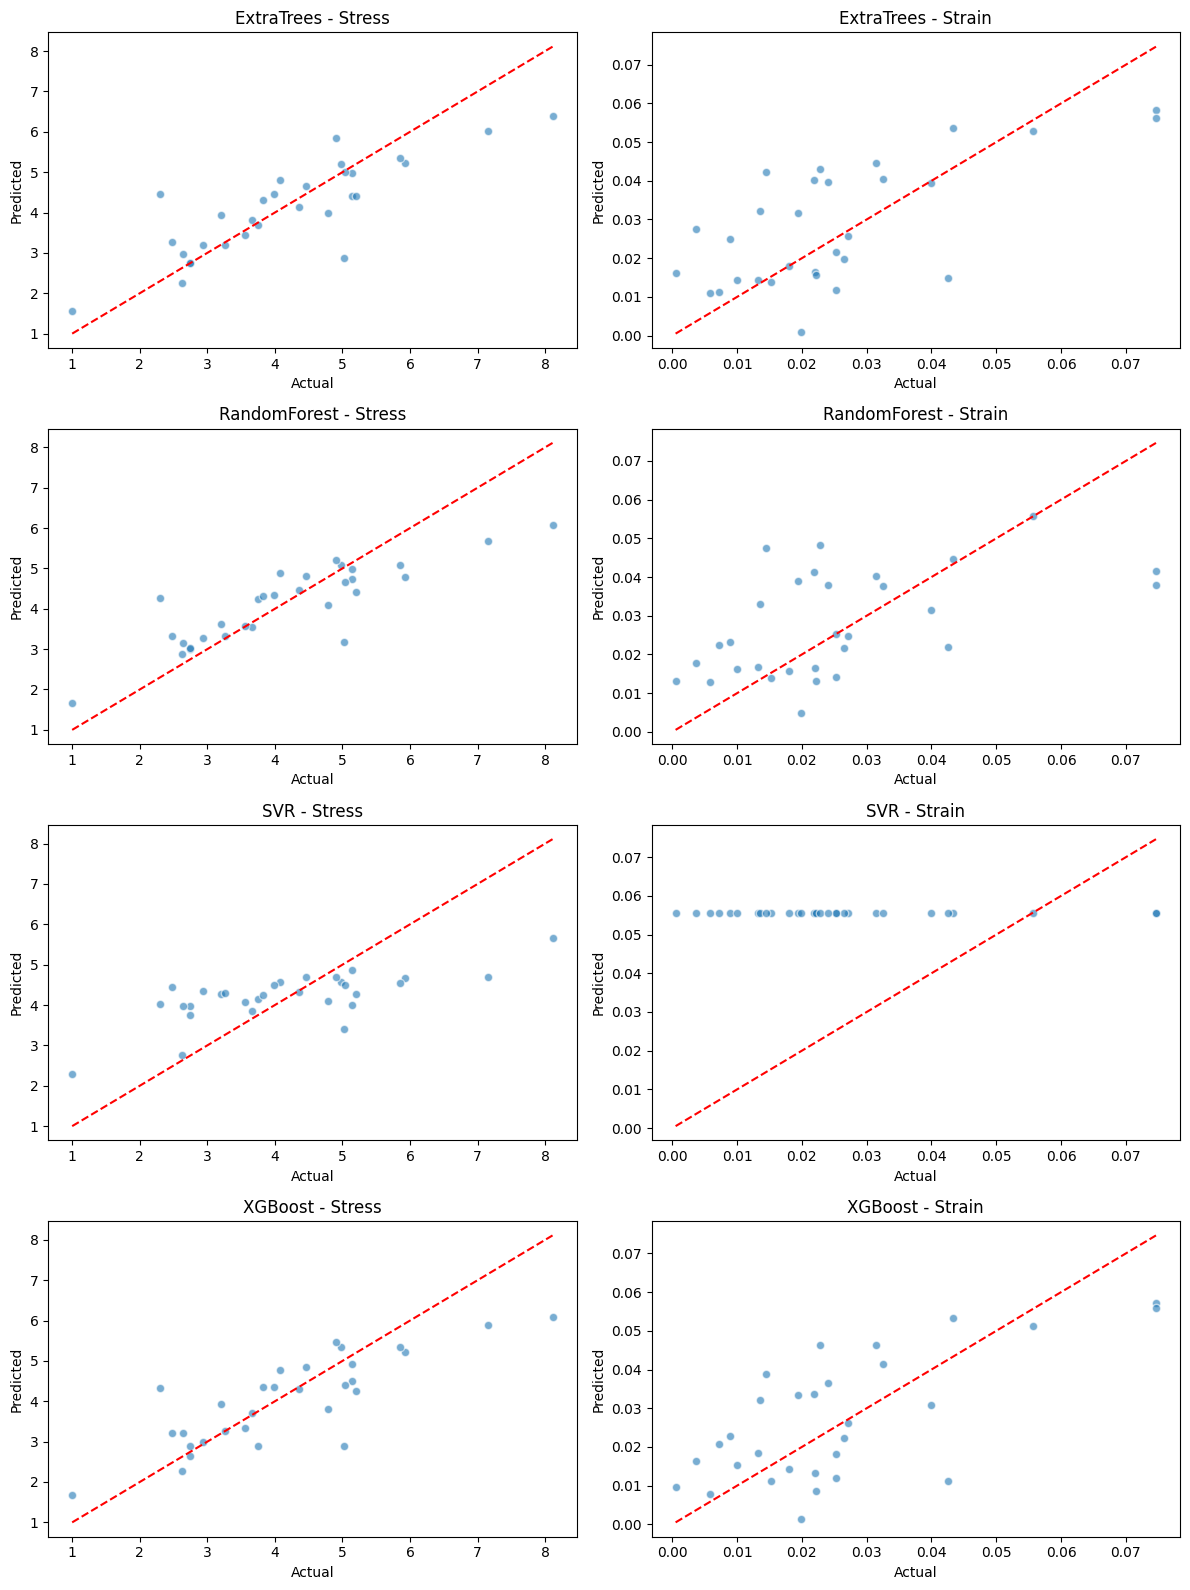

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predicted_vs_actual(y_true, y_pred, title, ax):
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='w')
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(title)

fig, axes = plt.subplots(len(models_to_test), 2, figsize=(12, 4*len(models_to_test)))
plt.subplots_adjust(hspace=0.4)

for i, (m_name, model) in enumerate(models_to_test.items()):
    # We'll visualize Scenario 3 (Clean Separate) as it's the best approach
    pipe_stress = build_pipeline(model, X_clean_tr)
    pipe_stress.fit(X_clean_tr, y_clean_str_tr)
    pred_str = pipe_stress.predict(X_clean_te)
    
    pipe_strain = build_pipeline(model, X_clean_tr)
    pipe_strain.fit(X_clean_tr, y_clean_stn_tr)
    pred_stn_log = pipe_strain.predict(X_clean_te)
    
    # Transform strain back
    pred_stn = np.expm1(pred_stn_log)
    actual_stn = np.expm1(y_clean_stn_te)
    
    plot_predicted_vs_actual(y_clean_str_te, pred_str, f'{m_name} - Stress', axes[i,0])
    plot_predicted_vs_actual(actual_stn, pred_stn, f'{m_name} - Strain', axes[i,1])

plt.tight_layout()
plt.show()

## Step 11 — Final Inference Implementation
The `ECCPredictor` class builds a separate pipeline for Stress and Strain.  
The Strain pipeline uses **`TransformedTargetRegressor` + `QuantileTransformer`** with zero leakage.

In [ ]:
import copy, joblib

class ECCPredictor:
    """
    Train and predict Second Stress and Second Strain.
    Strain pipeline uses TransformedTargetRegressor + QuantileTransformer
    to normalise the skewed target without data leakage.
    """

    def __init__(self, model=None):
        if model is None:
            model = ExtraTreesRegressor(random_state=42, n_estimators=200)
        self.model = model
        self.pipe_stress = None
        self.pipe_strain = None

    def train(self, X_train, y_stress_train, y_strain_train):
        # Stress — plain pipeline
        self.pipe_stress = build_pipeline(copy.deepcopy(self.model), X_train)
        self.pipe_stress.fit(X_train, y_stress_train)

        # Strain — TransformedTargetRegressor + QuantileTransformer
        self.pipe_strain = build_strain_pipeline(copy.deepcopy(self.model), X_train)
        self.pipe_strain.fit(X_train, y_strain_train)

        print("Training complete.")

    def predict(self, X_new):
        stress_pred = self.pipe_stress.predict(X_new)
        strain_pred = self.pipe_strain.predict(X_new)   # already inverse-transformed
        return pd.DataFrame({
            "Predicted Stress": stress_pred,
            "Predicted Strain": strain_pred
        })

    def save(self, path="ecc_predictor.joblib"):
        joblib.dump(self, path)
        print(f"Saved to {path}")

    @staticmethod
    def load(path="ecc_predictor.joblib"):
        return joblib.load(path)


# Demo
predictor = ECCPredictor()
predictor.train(X_clean_tr, y_clean_str_tr, y_clean_stn_tr)

sample = X_clean_te.head(5)
print("Sample predictions:")
print(predictor.predict(sample))
print("Actual values:")
print(pd.DataFrame({"Actual Stress": y_clean_str_te.head(5).values,
                     "Actual Strain": y_clean_stn_te.head(5).values}))
